In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, log_loss, roc_auc_score,
    roc_curve, auc, matthews_corrcoef
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.calibration import CalibratedClassifierCV

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ==============================
# 2. LOAD DATA
# ==============================
train_df = pd.read_excel("/content/drive/MyDrive/CBC Data/CBC indices data set/5778-Non-SMOTE-NC.xlsx")

test_df = pd.read_excel("/content/drive/MyDrive/CBC Data/CBC indices data set/625-External data.xlsx")

In [ ]:
# ==============================
# 3. CLEAN
# ==============================
def clean(df):
    df.columns = df.columns.str.strip().str.upper()
    return df

train_df = clean(train_df)
test_df  = clean(test_df)

drop_cols = ['NO','SEX','AGE']
train_df = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
test_df  = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])

In [ ]:
# ==============================
# 4. FEATURE ENGINEERING
# ==============================
def fe(df):
    df = df.copy()
    eps = 1e-6
    df['MENTZER'] = df['MCV']/(df['RBC']+eps)
    df['RDW_MCV'] = df['RDW']/(df['MCV']+eps)
    df['MCV_RBC'] = df['MCV']/(df['RBC']+eps)
    df['MCH_MCV'] = df['MCH']/(df['MCV']+eps)
    return df

train_df = fe(train_df)
test_df  = fe(test_df)

In [ ]:
# ==============================
# 5. FEATURES
# ==============================
features = [
    'RBC','MCV','MCH','RDW','HGB','HCT',
    'MENTZER','RDW_MCV','MCV_RBC','MCH_MCV'
]

TARGET = 'LABEL'

X = train_df[features]
y = train_df[TARGET]

X_test = test_df[features]
y_test = test_df[TARGET]

In [ ]:
# ==============================
# 6. SPLIT (VALIDATION FROM TRAIN)
# ==============================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
# ==============================
# 🔥 7. CLASS WEIGHTS (NO SMOTE)
# ==============================
weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [ ]:
# ==============================
# 🔥 8. MODEL (ANTI-OVERFITTING XGB)
# ==============================
bbase_model = XGBClassifier(
    n_estimators=800,          # ↓ from 1500
    max_depth=3,
    learning_rate=0.02,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=1.5,                 # ↑ stronger regularization
    min_child_weight=6,        # ↑ safer splits
    reg_alpha=1.5,
    reg_lambda=4.0,
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42
)

base_model.fit(
    X_train, y_train,
    sample_weight=weights,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Calibration
model = CalibratedClassifierCV(base_model, method='isotonic', cv=3)
model.fit(X_train, y_train)

CalibratedClassifierCV(cv=3,
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=0.7,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric='mlogloss',
                                               feature_types=None,
                                               feature_weights=None, gamma=1.0,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.02, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=3,
                                               max_leaves=None,
                                               min_child_weight=5, missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=1500, n_jobs=None,
                                               num_class=4, ...),
                       method='isotonic')

In [ ]:
# ==============================
# 9. PREDICTION
# ==============================
y_train_pred = model.predict(X_train)
y_val_pred   = model.predict(X_val)
y_test_pred  = model.predict(X_test)

y_val_prob   = model.predict_proba(X_val)
y_test_prob  = model.predict_proba(X_test)

In [ ]:
# ==============================
# 🔥 9.5 OVERALL ACCURACY
# ==============================
print("\n===== OVERALL ACCURACY =====")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))


===== OVERALL ACCURACY =====
Train Accuracy: 0.8117697966248377
Validation Accuracy: 0.7967128027681661
Test Accuracy: 0.7744


In [ ]:
# ==============================
# 🔥 10. METRICS
# ==============================
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    spec_list = []
    for i in range(len(cm)):
        TP = cm[i,i]
        FN = np.sum(cm[i,:]) - TP
        FP = np.sum(cm[:,i]) - TP
        TN = np.sum(cm) - (TP + FN + FP)
        spec_list.append(TN / (TN + FP + 1e-6))
    return np.mean(spec_list)


def evaluate(y_true, y_pred, y_prob, name):
    print(f"\n===== {name} =====")

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1:", f1_score(y_true, y_pred, average='weighted'))
    print("MCC:", matthews_corrcoef(y_true, y_pred))
    print("Specificity:", specificity_score(y_true, y_pred))
    print("LogLoss:", log_loss(y_true, y_prob, labels=[0,1,2,3]))

    print("AUC Macro:",
          roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro'))
    print("AUC Weighted:",
          roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted'))

In [ ]:
# ==============================
# 11. EVALUATION
# ==============================
evaluate(y_val, y_val_pred, y_val_prob, "VALIDATION")
evaluate(y_test, y_test_pred, y_test_prob, "TEST")


===== VALIDATION =====
Accuracy: 0.7967128027681661
Precision: 0.7855338031569434
Recall: 0.7967128027681661
F1: 0.7849188389251893
MCC: 0.6552103428715408
Specificity: 0.9190638053499625
LogLoss: 0.5324016199635355
AUC Macro: 0.9203812610266534
AUC Weighted: 0.9397457793944176

===== TEST =====
Accuracy: 0.7744
Precision: 0.7712007235242634
Recall: 0.7744
F1: 0.7667240950938864
MCC: 0.6761177667880474
Specificity: 0.9217959697868581
LogLoss: 1.2161955381324918
AUC Macro: 0.9124557038753484
AUC Weighted: 0.9259993465993466


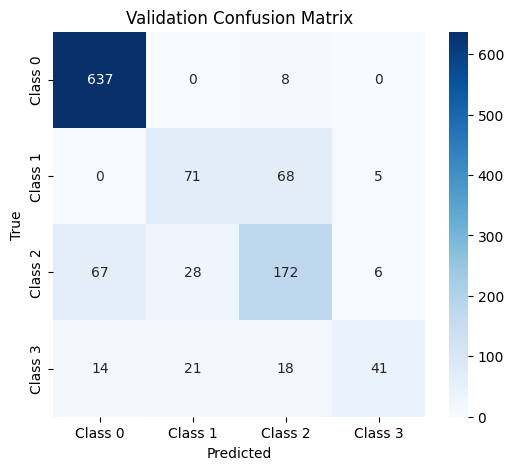

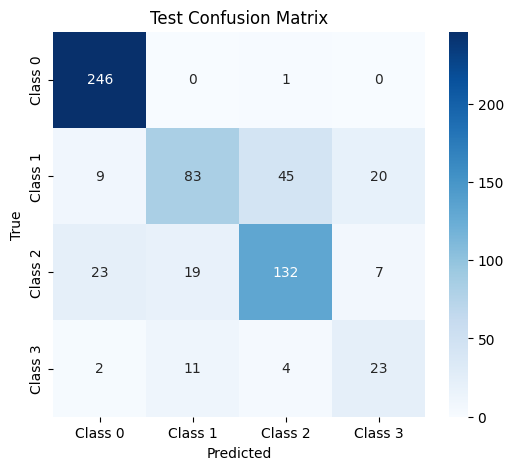

In [ ]:
# ==============================
# 🔥 12. CONFUSION MATRIX PLOT
# ==============================
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Class 0","Class 1","Class 2","Class 3"]

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()


plot_confusion_matrix(y_val, y_val_pred, "Validation Confusion Matrix")
plot_confusion_matrix(y_test, y_test_pred, "Test Confusion Matrix")

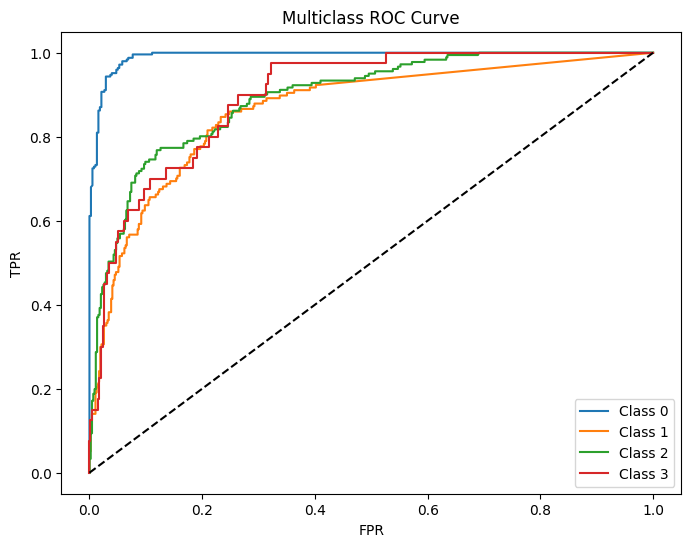

In [ ]:
# ==============================
# 🔥 13. MULTICLASS ROC CURVE
# ==============================
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])

plt.figure(figsize=(8,6))

for i in range(4):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_prob[:, i])
    plt.plot(fpr, tpr, label=f'Class {i}')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.show()

In [2]:


# ==============================
# 0. INSTALL SHAP
# ==============================
!pip install shap -q



===== OVERALL ACCURACY =====
Train Accuracy: 0.7964084811769797
Validation Accuracy: 0.7993079584775087
Test Accuracy: 0.7792

===== VALIDATION =====
Accuracy: 0.7993079584775087
Precision: 0.7867606836869504
Recall: 0.7993079584775087
F1: 0.7868151938135537
MCC: 0.6593522595849045
Specificity: 0.9195125909848103
LogLoss: 0.554964523805076
AUC Macro: 0.9222254957060326
AUC Weighted: 0.9411070290193934

===== TEST =====
Accuracy: 0.7792
Precision: 0.7773451787891154
Recall: 0.7792
F1: 0.773440503413938
MCC: 0.6831999241088109
Specificity: 0.924106109590592
LogLoss: 1.2099332447515991
AUC Macro: 0.9155304809368605
AUC Weighted: 0.9281882132682132


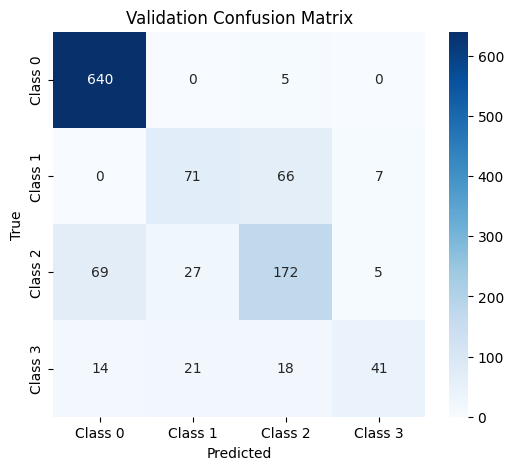

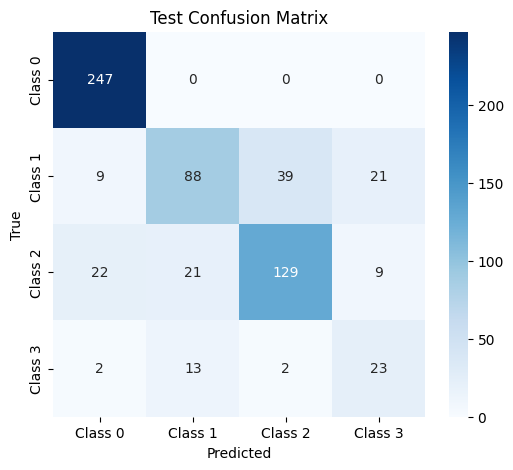

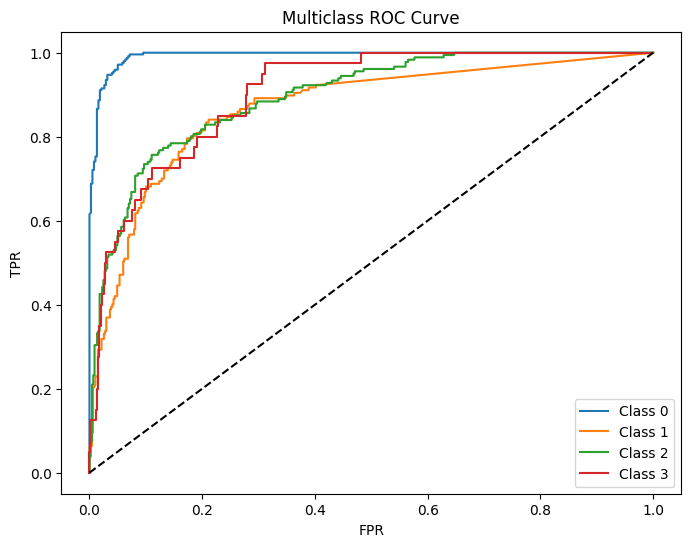


===== SHAP ANALYSIS =====

Generating SHAP Bar Plot...


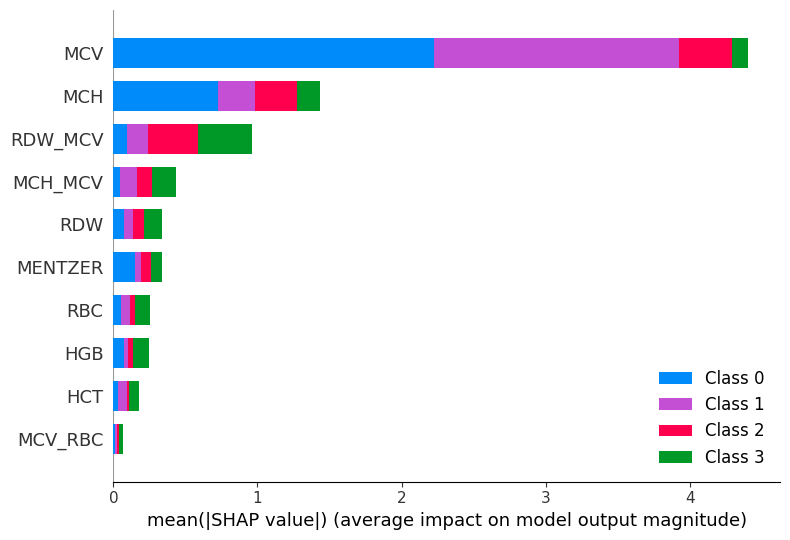


Generating SHAP Summary Plot...


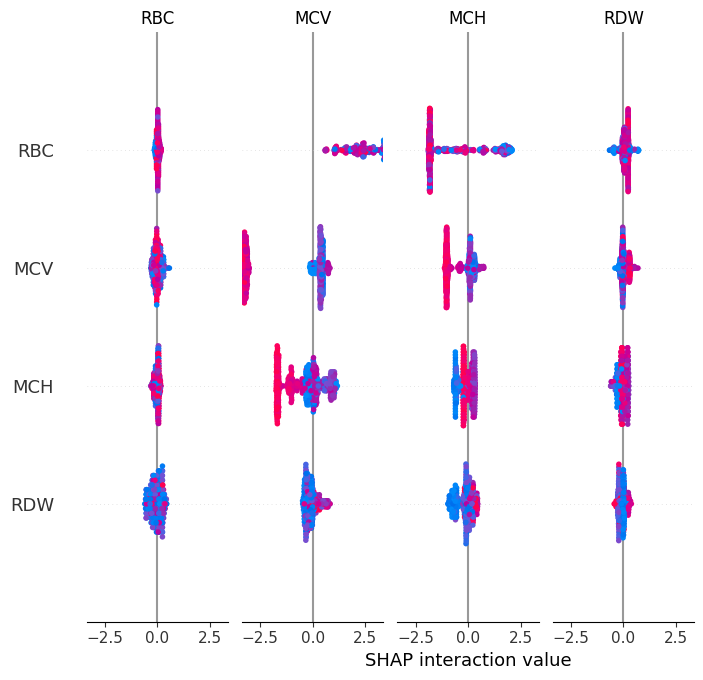

In [3]:


# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, log_loss, roc_auc_score,
    roc_curve, auc, matthews_corrcoef
)

from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.calibration import CalibratedClassifierCV

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import shap

# ==============================
# 2. LOAD DATA
# ==============================
train_df = pd.read_excel(
    "/content/drive/MyDrive/CBC Data/CBC indices data set/5778-Non-SMOTE-NC.xlsx"
)

test_df = pd.read_excel(
    "/content/drive/MyDrive/CBC Data/CBC indices data set/625-External data.xlsx"
)

# ==============================
# 3. CLEAN
# ==============================
def clean(df):
    df.columns = df.columns.str.strip().str.upper()
    return df

train_df = clean(train_df)
test_df  = clean(test_df)

drop_cols = ['NO','SEX','AGE']

train_df = train_df.drop(
    columns=[c for c in drop_cols if c in train_df.columns]
)

test_df = test_df.drop(
    columns=[c for c in drop_cols if c in test_df.columns]
)

# ==============================
# 4. FEATURE ENGINEERING
# ==============================
def fe(df):
    df = df.copy()

    eps = 1e-6

    df['MENTZER'] = df['MCV'] / (df['RBC'] + eps)
    df['RDW_MCV'] = df['RDW'] / (df['MCV'] + eps)
    df['MCV_RBC'] = df['MCV'] / (df['RBC'] + eps)
    df['MCH_MCV'] = df['MCH'] / (df['MCV'] + eps)

    return df

train_df = fe(train_df)
test_df  = fe(test_df)

# ==============================
# 5. FEATURES
# ==============================
features = [
    'RBC',
    'MCV',
    'MCH',
    'RDW',
    'HGB',
    'HCT',
    'MENTZER',
    'RDW_MCV',
    'MCV_RBC',
    'MCH_MCV'
]

TARGET = 'LABEL'

X = train_df[features]
y = train_df[TARGET]

X_test = test_df[features]
y_test = test_df[TARGET]

# ==============================
# 6. SPLIT
# ==============================
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ==============================
# 7. CLASS WEIGHTS
# ==============================
weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# ==============================
# 8. XGBOOST MODEL
# ==============================
base_model = XGBClassifier(
    n_estimators=800,
    max_depth=3,
    learning_rate=0.02,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=1.5,
    min_child_weight=6,
    reg_alpha=1.5,
    reg_lambda=4.0,
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42
)

base_model.fit(
    X_train,
    y_train,
    sample_weight=weights,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# ==============================
# 9. CALIBRATION
# ==============================
model = CalibratedClassifierCV(
    base_model,
    method='isotonic',
    cv=3
)

model.fit(X_train, y_train)

# ==============================
# 10. PREDICTIONS
# ==============================
y_train_pred = model.predict(X_train)
y_val_pred   = model.predict(X_val)
y_test_pred  = model.predict(X_test)

y_val_prob   = model.predict_proba(X_val)
y_test_prob  = model.predict_proba(X_test)

# ==============================
# 11. ACCURACY
# ==============================
print("\n===== OVERALL ACCURACY =====")

print("Train Accuracy:",
      accuracy_score(y_train, y_train_pred))

print("Validation Accuracy:",
      accuracy_score(y_val, y_val_pred))

print("Test Accuracy:",
      accuracy_score(y_test, y_test_pred))

# ==============================
# 12. METRICS
# ==============================
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    spec_list = []

    for i in range(len(cm)):

        TP = cm[i, i]

        FN = np.sum(cm[i, :]) - TP
        FP = np.sum(cm[:, i]) - TP

        TN = np.sum(cm) - (TP + FN + FP)

        spec_list.append(
            TN / (TN + FP + 1e-6)
        )

    return np.mean(spec_list)

# ==============================
# 13. EVALUATION FUNCTION
# ==============================
def evaluate(y_true, y_pred, y_prob, name):

    print(f"\n===== {name} =====")

    print("Accuracy:",
          accuracy_score(y_true, y_pred))

    print("Precision:",
          precision_score(
              y_true,
              y_pred,
              average='weighted'
          ))

    print("Recall:",
          recall_score(
              y_true,
              y_pred,
              average='weighted'
          ))

    print("F1:",
          f1_score(
              y_true,
              y_pred,
              average='weighted'
          ))

    print("MCC:",
          matthews_corrcoef(
              y_true,
              y_pred
          ))

    print("Specificity:",
          specificity_score(
              y_true,
              y_pred
          ))

    print("LogLoss:",
          log_loss(
              y_true,
              y_prob,
              labels=[0,1,2,3]
          ))

    print("AUC Macro:",
          roc_auc_score(
              y_true,
              y_prob,
              multi_class='ovr',
              average='macro'
          ))

    print("AUC Weighted:",
          roc_auc_score(
              y_true,
              y_prob,
              multi_class='ovr',
              average='weighted'
          ))

# ==============================
# 14. EVALUATION
# ==============================
evaluate(
    y_val,
    y_val_pred,
    y_val_prob,
    "VALIDATION"
)

evaluate(
    y_test,
    y_test_pred,
    y_test_prob,
    "TEST"
)

# ==============================
# 15. CONFUSION MATRIX
# ==============================
def plot_confusion_matrix(y_true, y_pred, title):

    cm = confusion_matrix(y_true, y_pred)

    labels = [
        "Class 0",
        "Class 1",
        "Class 2",
        "Class 3"
    ]

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)

    plt.show()

plot_confusion_matrix(
    y_val,
    y_val_pred,
    "Validation Confusion Matrix"
)

plot_confusion_matrix(
    y_test,
    y_test_pred,
    "Test Confusion Matrix"
)

# ==============================
# 16. ROC CURVE
# ==============================
y_test_bin = label_binarize(
    y_test,
    classes=[0,1,2,3]
)

plt.figure(figsize=(8,6))

for i in range(4):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_test_prob[:, i]
    )

    plt.plot(
        fpr,
        tpr,
        label=f'Class {i}'
    )

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("FPR")
plt.ylabel("TPR")

plt.title("Multiclass ROC Curve")

plt.legend()

plt.show()

# ==============================
# 17. SHAP ANALYSIS
# ==============================
print("\n===== SHAP ANALYSIS =====")

# Create SHAP explainer
explainer = shap.TreeExplainer(base_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# ==============================
# SHAP BAR PLOT
# ==============================
print("\nGenerating SHAP Bar Plot...")

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=features,
    plot_type="bar"
)

# ==============================
# SHAP SUMMARY PLOT
# ==============================
print("\nGenerating SHAP Summary Plot...")

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=features
)